In [1]:
import sys
import pandas as pd
import os
import numpy as np
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

ROOT = Path("..") if Path("../configs").exists() else Path(".")
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT))

from src.hcm_transcription.mapping import MAPPING
from src.hcm_transcription.utils import ORNAMENT_MAPPING, df_to_anno, extract_ornament_segments

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
raga_names = MAPPING.keys()
data_home = str(ROOT)
annotation_base = str(ROOT / "Ornamentation-In-Hindustani-Vocals-Dataset")

segments = extract_ornament_segments(raga_names, data_home, annotation_base)

Loading Aahir Bhairon...
  Pitch: ../saraga1.5_hindustani/Geetinandan : Part-3 by Ajoy Chakrabarty/Aahir Bhairon/Aahir Bhairon.pitch.txt
  Found 149 target ornaments out of 149 total
Loading Bairagi...
  Pitch: ../saraga1.5_hindustani/Geetinandan : Part-3 by Ajoy Chakrabarty/Bairagi/Bairagi.pitch.txt
  Found 89 target ornaments out of 89 total
Loading Bhairavi Dadra...
  Pitch: ../saraga1.5_hindustani/Raag Bihag & Bhairavi Dadra by Omkar Dadarkar/Bhairavi Dadra/Bhairavi Dadra.pitch.txt
  Found 96 target ornaments out of 96 total
Loading Irani Bhairavi...
  Pitch: ../saraga1.5_hindustani/New Signature by Brajeshwar Mukherjee/Irani Bhairavi Thumri/Irani Bhairavi Thumri.pitch.txt
  Found 103 target ornaments out of 103 total
Loading Kalavati...
  Pitch: ../saraga1.5_hindustani/Geetinandan : Part-3 by Ajoy Chakrabarty/Kalavati/Kalavati.pitch.txt
  Found 137 target ornaments out of 137 total
Loading Malkauns...
  Pitch: ../saraga1.5_hindustani/Geetinandan : Part-3 by Ajoy Chakrabarty/Malkau

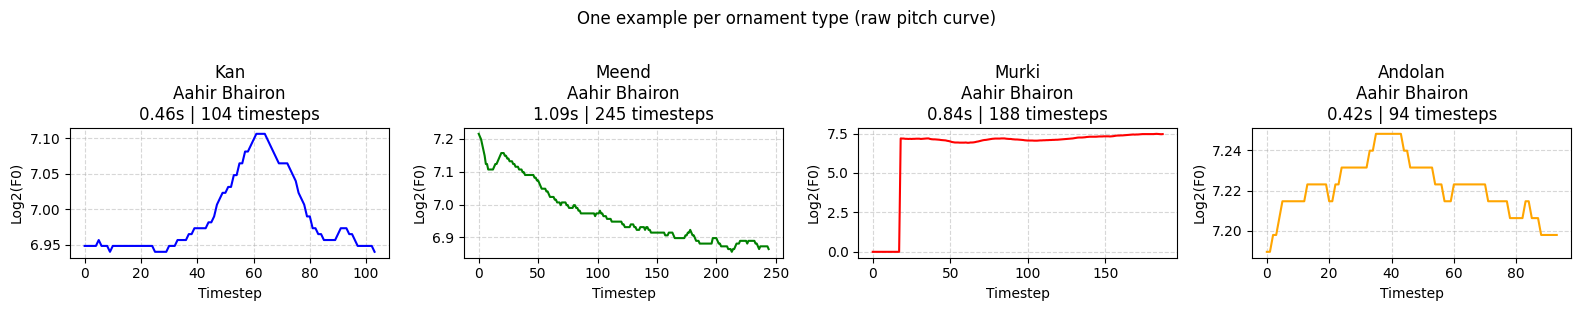

In [7]:
# Plot one example per class
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
colors = {"Kan": "blue", "Meend": "green", "Murki": "red", "Andolan": "orange"}

for ax, label in zip(axes, ["Kan", "Meend", "Murki", "Andolan"]):
    # Find first example of this label
    example = next((s for s in segments if s['label'] == label), None)
    
    if example is None:
        ax.set_title(f"{label}\n(not found)")
        continue
    
    curve = example['pitch_curve']
    ax.plot(curve, color=colors[label], linewidth=1.5)
    ax.set_title(f"{label}\n{example['raga']}\n{example['duration']:.2f}s | {len(curve)} timesteps")
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Log2(F0)")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("One example per ornament type (raw pitch curve)", y=1.02)
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd

# Build summary dataframe
df_segments = pd.DataFrame([{k: v for k, v in s.items() if k != "pitch_curve"} for s in segments])
df_segments['num_timesteps'] = [len(s['pitch_curve']) for s in segments]

print("=== Class Distribution ===")
print(df_segments['label'].value_counts())

print("\n=== Duration Stats per Class (seconds) ===")
print(df_segments.groupby('label')['duration'].describe().round(3))

print("\n=== Timestep Stats per Class ===")
print(df_segments.groupby('label')['num_timesteps'].describe().round(1))

print("\n=== Duration Stats per Raga ===")
print(df_segments.groupby('raga')['duration'].describe().round(3))

=== Class Distribution ===
label
Kan        480
Murki      434
Meend      430
Andolan     37
Name: count, dtype: int64

=== Duration Stats per Class (seconds) ===
         count   mean    std    min    25%    50%    75%    max
label                                                          
Andolan   37.0  0.976  1.019  0.107  0.276  0.575  1.443  4.644
Kan      480.0  0.434  0.371  0.055  0.222  0.320  0.522  2.771
Meend    430.0  0.869  0.611  0.174  0.518  0.706  1.020  4.889
Murki    434.0  1.231  0.829  0.017  0.653  0.990  1.567  5.203

=== Timestep Stats per Class ===
         count   mean    std   min    25%    50%    75%     max
label                                                          
Andolan   37.0  219.6  229.4  24.0   61.0  129.0  325.0  1045.0
Kan      480.0   97.6   83.4  12.0   50.0   72.0  118.0   624.0
Meend    430.0  195.5  137.5  39.0  117.0  159.0  229.8  1101.0
Murki    434.0  277.1  186.6   4.0  147.0  223.0  353.0  1171.0

=== Duration Stats per Raga ===
  

In [9]:
lengths = [len(s['pitch_curve']) for s in segments]
print(f"min: {min(lengths)}")
print(f"max: {max(lengths)}")
print(f"mean: {np.mean(lengths):.0f}")
print(f"95th percentile: {np.percentile(lengths, 95):.0f}")

min: 4
max: 1171
mean: 188
95th percentile: 513


In [10]:
def augment_pitch_curve(curve, noise_std=0.01, stretch_range=(0.8, 1.2)):
    """
    Applies random augmentations to a pitch curve:
    - Gaussian noise
    - Time stretching (resampling)
    """
    from scipy.signal import resample
    
    # Random time stretch
    stretch_factor = np.random.uniform(*stretch_range)
    new_length = int(len(curve) * stretch_factor)
    curve = resample(curve, new_length)
    
    # Add small Gaussian noise
    #curve = curve + np.random.normal(0, noise_std, len(curve))
    
    return curve


def augment_segments(segments, num_augmentations=2):
    """
    Augments each segment num_augmentations times and adds to dataset.
    """
    augmented = []
    for seg in segments:
        augmented.append(seg)  # keep original
        
        for _ in range(num_augmentations):
            aug_curve = augment_pitch_curve(seg['pitch_curve'].copy())
            augmented.append({
                "raga": seg['raga'],
                "label": seg['label'],
                "time_s": seg['time_s'],
                "time_e": seg['time_e'],
                "duration": seg['duration'],
                "pitch_curve": aug_curve
            })
    
    print(f"Original: {len(segments)} → Augmented: {len(augmented)} segments")
    return augmented

segments_aug = augment_segments(segments, num_augmentations=2)

Original: 1381 → Augmented: 4143 segments


### Preprocess

In [11]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

def prepare_tcn_input(segments, fixed_length=117):
    """
    Takes raw segments from extract_ornament_segments and prepares
    fixed-length numpy arrays for TCN training.
    """
    label_map = {"Kan": 0, "Meend": 1, "Murki": 2, "Andolan": 3}
    
    X, y = [], []
    skipped = 0

    # Filter too-short segments before processing
    segments = [s for s in segments if len(s['pitch_curve']) >= 20]
    
    for seg in segments:
        curve = seg['pitch_curve']
        label = seg['label']
        
        if label not in label_map:
            skipped += 1
            continue
        
        # Normalize each curve to zero mean and unit variance
        if curve.std() > 0:
            curve = (curve - curve.mean()) / curve.std()
        
        # Pad or truncate to fixed length
        if len(curve) < fixed_length:
            curve = np.pad(curve, (0, fixed_length - len(curve)), mode='constant')
        else:
            curve = curve[:fixed_length]
        
        X.append(curve)
        y.append(label_map[label])
    
    X = np.array(X, dtype=np.float32)[:, np.newaxis, :]  # (N, 1, fixed_length)
    y = np.array(y, dtype=np.int64)
    
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print(f"Skipped: {skipped}")
    print(f"Label distribution: { {k: int((y==v).sum()) for k,v in label_map.items()} }")
    
    return X, y, label_map


def get_dataloaders(X, y, batch_size=16, test_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )
    
    train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
    test_ds  = TensorDataset(torch.tensor(X_test),  torch.tensor(y_test))
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size)
    
    print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")
    return train_loader, test_loader

In [12]:
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=padding)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.norm1 = nn.BatchNorm1d(channels)
        self.norm2 = nn.BatchNorm1d(channels)

    def forward(self, x):
        out = self.relu(self.norm1(self.conv1(x)[:, :, :x.size(2)]))
        out = self.dropout(out)
        out = self.relu(self.norm2(self.conv2(out)[:, :, :x.size(2)]))
        return self.relu(out + x)  # residual connection


class OrnamentTCN(nn.Module):
    def __init__(self, input_size=1, num_classes=4, channels=32, kernel_size=3):
        super().__init__()
        self.input_proj = nn.Conv1d(input_size, channels, kernel_size=1)
        self.tcn = nn.Sequential(
            ResidualBlock(channels, kernel_size, dilation=1),
            ResidualBlock(channels, kernel_size, dilation=2),
            ResidualBlock(channels, kernel_size, dilation=4),
            ResidualBlock(channels, kernel_size, dilation=8),
        )
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)  # collapses any length to 1
        self.classifier = nn.Linear(channels, num_classes)

    def forward(self, x):
        out = self.input_proj(x)
        out = self.tcn(out)
        out = out.mean(dim=2)  # global average pooling
        return self.classifier(out)

In [13]:
from sklearn.utils.class_weight import compute_class_weight

def train_tcn(train_loader, test_loader, num_classes=4, epochs=30):
    model = OrnamentTCN(input_size=1, num_classes=num_classes)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # Handle class imbalance
    all_labels = train_loader.dataset.tensors[1].numpy()
    weights = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float))
    
    for epoch in range(epochs):
        # Train
        model.train()
        train_loss, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            correct += (preds.argmax(1) == yb).sum().item()
            total += len(yb)
        
        # Evaluate
        model.eval()
        test_correct, test_total = 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                preds = model(xb)
                test_correct += (preds.argmax(1) == yb).sum().item()
                test_total += len(yb)
        
        print(f"Epoch {epoch+1:02d} | "
              f"Loss: {train_loss/len(train_loader):.4f} | "
              f"Train Acc: {correct/total:.3f} | "
              f"Test Acc: {test_correct/test_total:.3f}")
    
    return model

In [14]:
# After running extract_ornament_segments
X, y, label_map = prepare_tcn_input(segments_aug, fixed_length=200)
train_loader, test_loader = get_dataloaders(X, y, batch_size=16)
model = train_tcn(train_loader, test_loader, epochs=30)

X shape: (4120, 1, 200)
y shape: (4120,)
Skipped: 0
Label distribution: {'Kan': 1420, 'Meend': 1290, 'Murki': 1299, 'Andolan': 111}
Train: 3296 | Test: 824
Epoch 01 | Loss: 1.2468 | Train Acc: 0.518 | Test Acc: 0.595
Epoch 02 | Loss: 1.1449 | Train Acc: 0.623 | Test Acc: 0.621
Epoch 03 | Loss: 1.0852 | Train Acc: 0.644 | Test Acc: 0.636
Epoch 04 | Loss: 1.0388 | Train Acc: 0.657 | Test Acc: 0.587
Epoch 05 | Loss: 1.0046 | Train Acc: 0.666 | Test Acc: 0.648
Epoch 06 | Loss: 0.9703 | Train Acc: 0.666 | Test Acc: 0.684
Epoch 07 | Loss: 0.9569 | Train Acc: 0.677 | Test Acc: 0.664
Epoch 08 | Loss: 0.9275 | Train Acc: 0.676 | Test Acc: 0.664
Epoch 09 | Loss: 0.9123 | Train Acc: 0.682 | Test Acc: 0.703
Epoch 10 | Loss: 0.9005 | Train Acc: 0.682 | Test Acc: 0.637
Epoch 11 | Loss: 0.8686 | Train Acc: 0.686 | Test Acc: 0.631
Epoch 12 | Loss: 0.8673 | Train Acc: 0.679 | Test Acc: 0.677
Epoch 13 | Loss: 0.8508 | Train Acc: 0.687 | Test Acc: 0.695
Epoch 14 | Loss: 0.8312 | Train Acc: 0.695 | Test A

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model, test_loader, label_map):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in test_loader:
            xb, yb = batch[0], batch[1]
            preds = model(xb).argmax(1)
            all_preds.extend(preds.numpy())
            all_labels.extend(yb.numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    idx_to_label = {v: k for k, v in label_map.items()}
    target_names = [idx_to_label[i] for i in range(len(label_map))]
    
    # Classification report
    print("=== Classification Report ===")
    print(classification_report(all_labels, all_preds, target_names=target_names))
    
    # Explicit per-class metrics
    precision = precision_score(all_labels, all_preds, average=None)
    recall    = recall_score(all_labels, all_preds, average=None)
    f1        = f1_score(all_labels, all_preds, average=None)
    
    print("=== Per-class Metrics ===")
    for i, name in enumerate(target_names):
        print(f"{name:10s} | Precision: {precision[i]:.3f} | Recall: {recall[i]:.3f} | F1: {f1[i]:.3f}")
    
    # Macro averages
    print(f"\n{'Macro avg':10s} | Precision: {precision.mean():.3f} | Recall: {recall.mean():.3f} | F1: {f1.mean():.3f}")
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
    
    return all_preds, all_labels, precision, recall, f1

=== Classification Report ===
              precision    recall  f1-score   support

         Kan       0.74      0.56      0.64       284
       Meend       0.72      0.79      0.75       258
       Murki       0.83      0.75      0.79       260
     Andolan       0.23      0.91      0.36        22

    accuracy                           0.70       824
   macro avg       0.63      0.75      0.64       824
weighted avg       0.75      0.70      0.71       824

=== Per-class Metrics ===
Kan        | Precision: 0.737 | Recall: 0.563 | F1: 0.639
Meend      | Precision: 0.720 | Recall: 0.787 | F1: 0.752
Murki      | Precision: 0.827 | Recall: 0.754 | F1: 0.789
Andolan    | Precision: 0.227 | Recall: 0.909 | F1: 0.364

Macro avg  | Precision: 0.628 | Recall: 0.753 | F1: 0.636


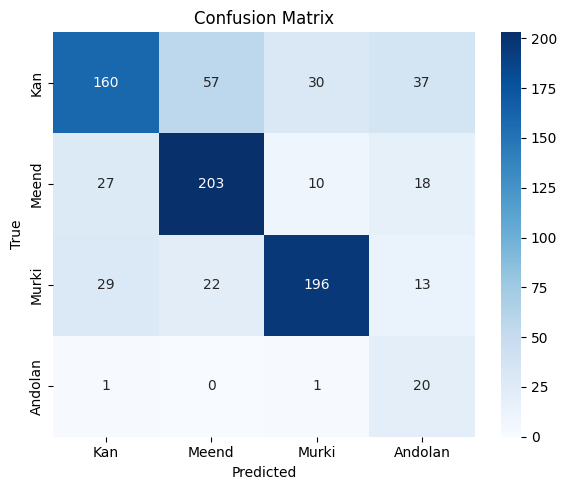

Precision: [0.73732719 0.71985816 0.82700422 0.22727273]
Recall:    [0.56338028 0.78682171 0.75384615 0.90909091]
F1:        [0.63872255 0.75185185 0.78873239 0.36363636]


In [16]:
all_preds, all_labels, precision, recall, f1 = evaluate_model(model, test_loader, label_map)

# Print as arrays
print("Precision:", precision)
print("Recall:   ", recall)
print("F1:       ", f1)

#### Without data augmentation 

##### loss:0.9083, trainacc = 0.643, testacc = 0.589
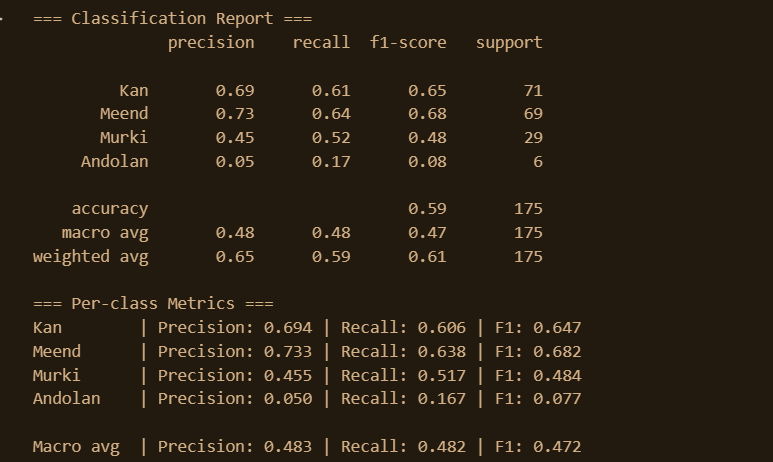

#### Cross validation for augmented data

In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

def cross_validate_tcn(X, y, label_map, n_splits=5, epochs=30, batch_size=16):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    idx_to_label = {v: k for k, v in label_map.items()}
    target_names = [idx_to_label[i] for i in range(len(label_map))]
    
    fold_results = []
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X.reshape(len(X), -1), y)):
        print(f"\n{'='*50}")
        print(f"FOLD {fold+1}/{n_splits}")
        print(f"{'='*50}")
        
        # Split using indices directly on numpy arrays
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Use TensorDataset like your get_dataloaders
        train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
        test_ds  = TensorDataset(torch.tensor(X_test),  torch.tensor(y_test))
        
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        test_loader  = DataLoader(test_ds,  batch_size=batch_size)
        
        # Train
        model = train_tcn(train_loader, test_loader,
                          num_classes=len(label_map), epochs=epochs)
        
        # Evaluate
        print(f"\n--- Fold {fold+1} Evaluation ---")
        all_preds, all_labels, precision, recall, f1 = evaluate_model(
            model, test_loader, label_map
        )
        
        acc    = (all_preds == all_labels).mean()
        f1_mac = f1.mean()
        
        fold_results.append({
            "fold": fold + 1,
            "accuracy": acc,
            "macro_f1": f1_mac,
            "precision": precision,
            "recall": recall,
            "per_class_f1": f1,
            "all_preds": all_preds,
            "all_labels": all_labels
        })
    
    # Summary
    print(f"\n{'='*50}")
    print("CROSS VALIDATION SUMMARY")
    print(f"{'='*50}")
    
    accs = [r['accuracy'] for r in fold_results]
    f1s  = [r['macro_f1'] for r in fold_results]
    print(f"\nAccuracy: {np.mean(accs):.3f} ± {np.std(accs):.3f}")
    print(f"Macro F1: {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
    
    print("\nPer-class metrics across folds (mean ± std):")
    print(f"{'Class':10s} | {'Precision':>15s} | {'Recall':>15s} | {'F1':>15s}")
    print("-" * 65)
    for i, name in enumerate(target_names):
        prec_scores = [r['precision'][i]    for r in fold_results]
        rec_scores  = [r['recall'][i]       for r in fold_results]
        f1_scores   = [r['per_class_f1'][i] for r in fold_results]
        print(f"{name:10s} | "
              f"{np.mean(prec_scores):.3f} ± {np.std(prec_scores):.3f}  | "
              f"{np.mean(rec_scores):.3f} ± {np.std(rec_scores):.3f}  | "
              f"{np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
    
    # Combined confusion matrix
    all_preds_combined  = np.concatenate([r['all_preds']  for r in fold_results])
    all_labels_combined = np.concatenate([r['all_labels'] for r in fold_results])
    
    cm = confusion_matrix(all_labels_combined, all_preds_combined)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Combined Confusion Matrix (all folds)")
    plt.tight_layout()
    plt.show()
    
    return fold_results

X shape: (4120, 1, 117)
y shape: (4120,)
Skipped: 0
Label distribution: {'Kan': 1420, 'Meend': 1290, 'Murki': 1299, 'Andolan': 111}

FOLD 1/5
Epoch 01 | Loss: 1.2966 | Train Acc: 0.519 | Test Acc: 0.557
Epoch 02 | Loss: 1.1942 | Train Acc: 0.574 | Test Acc: 0.590
Epoch 03 | Loss: 1.1467 | Train Acc: 0.570 | Test Acc: 0.563
Epoch 04 | Loss: 1.1004 | Train Acc: 0.608 | Test Acc: 0.559
Epoch 05 | Loss: 1.0919 | Train Acc: 0.602 | Test Acc: 0.653
Epoch 06 | Loss: 1.0232 | Train Acc: 0.636 | Test Acc: 0.621
Epoch 07 | Loss: 0.9949 | Train Acc: 0.634 | Test Acc: 0.600
Epoch 08 | Loss: 0.9677 | Train Acc: 0.648 | Test Acc: 0.597
Epoch 09 | Loss: 0.9494 | Train Acc: 0.644 | Test Acc: 0.665
Epoch 10 | Loss: 0.9490 | Train Acc: 0.645 | Test Acc: 0.652
Epoch 11 | Loss: 0.9261 | Train Acc: 0.652 | Test Acc: 0.681
Epoch 12 | Loss: 0.9145 | Train Acc: 0.651 | Test Acc: 0.681
Epoch 13 | Loss: 0.8910 | Train Acc: 0.660 | Test Acc: 0.670
Epoch 14 | Loss: 0.8849 | Train Acc: 0.667 | Test Acc: 0.677
Epoc

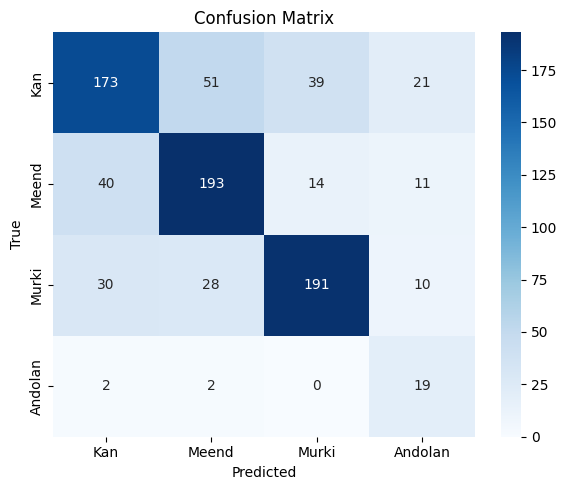


FOLD 2/5
Epoch 01 | Loss: 1.2896 | Train Acc: 0.503 | Test Acc: 0.580
Epoch 02 | Loss: 1.2200 | Train Acc: 0.559 | Test Acc: 0.518
Epoch 03 | Loss: 1.1608 | Train Acc: 0.589 | Test Acc: 0.564
Epoch 04 | Loss: 1.1117 | Train Acc: 0.598 | Test Acc: 0.613
Epoch 05 | Loss: 1.0770 | Train Acc: 0.623 | Test Acc: 0.630
Epoch 06 | Loss: 1.0543 | Train Acc: 0.638 | Test Acc: 0.612
Epoch 07 | Loss: 1.0180 | Train Acc: 0.634 | Test Acc: 0.641
Epoch 08 | Loss: 0.9975 | Train Acc: 0.647 | Test Acc: 0.671
Epoch 09 | Loss: 0.9619 | Train Acc: 0.659 | Test Acc: 0.617
Epoch 10 | Loss: 0.9572 | Train Acc: 0.658 | Test Acc: 0.633
Epoch 11 | Loss: 0.9339 | Train Acc: 0.661 | Test Acc: 0.631
Epoch 12 | Loss: 0.9238 | Train Acc: 0.665 | Test Acc: 0.652
Epoch 13 | Loss: 0.9044 | Train Acc: 0.653 | Test Acc: 0.635
Epoch 14 | Loss: 0.8762 | Train Acc: 0.683 | Test Acc: 0.680
Epoch 15 | Loss: 0.8837 | Train Acc: 0.677 | Test Acc: 0.619
Epoch 16 | Loss: 0.8828 | Train Acc: 0.673 | Test Acc: 0.606
Epoch 17 | Los

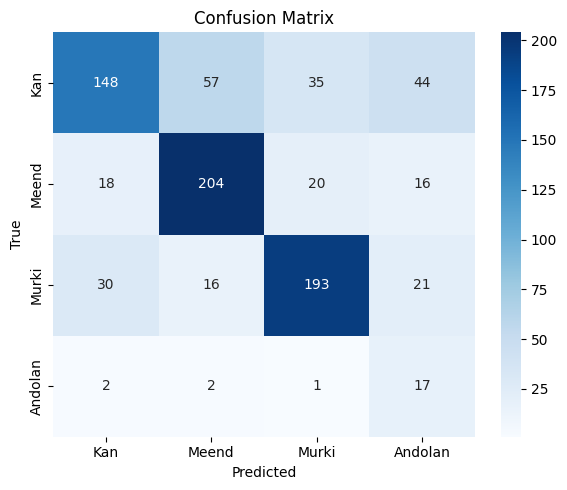


FOLD 3/5
Epoch 01 | Loss: 1.3059 | Train Acc: 0.508 | Test Acc: 0.578
Epoch 02 | Loss: 1.2231 | Train Acc: 0.565 | Test Acc: 0.568
Epoch 03 | Loss: 1.1594 | Train Acc: 0.568 | Test Acc: 0.642
Epoch 04 | Loss: 1.1240 | Train Acc: 0.576 | Test Acc: 0.649
Epoch 05 | Loss: 1.0965 | Train Acc: 0.593 | Test Acc: 0.650
Epoch 06 | Loss: 1.0497 | Train Acc: 0.608 | Test Acc: 0.665
Epoch 07 | Loss: 1.0238 | Train Acc: 0.617 | Test Acc: 0.686
Epoch 08 | Loss: 1.0029 | Train Acc: 0.623 | Test Acc: 0.647
Epoch 09 | Loss: 0.9866 | Train Acc: 0.636 | Test Acc: 0.704
Epoch 10 | Loss: 0.9680 | Train Acc: 0.629 | Test Acc: 0.681
Epoch 11 | Loss: 0.9272 | Train Acc: 0.653 | Test Acc: 0.557
Epoch 12 | Loss: 0.9073 | Train Acc: 0.650 | Test Acc: 0.655
Epoch 13 | Loss: 0.9021 | Train Acc: 0.661 | Test Acc: 0.714
Epoch 14 | Loss: 0.9022 | Train Acc: 0.654 | Test Acc: 0.701
Epoch 15 | Loss: 0.8735 | Train Acc: 0.671 | Test Acc: 0.650
Epoch 16 | Loss: 0.8598 | Train Acc: 0.661 | Test Acc: 0.687
Epoch 17 | Los

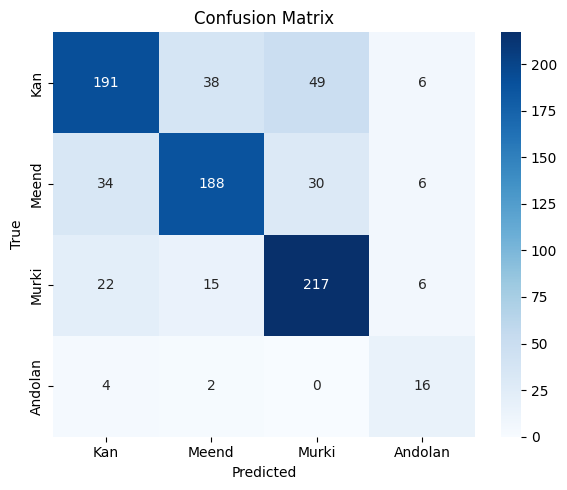


FOLD 4/5
Epoch 01 | Loss: 1.2886 | Train Acc: 0.515 | Test Acc: 0.326
Epoch 02 | Loss: 1.2020 | Train Acc: 0.550 | Test Acc: 0.586
Epoch 03 | Loss: 1.1362 | Train Acc: 0.591 | Test Acc: 0.633
Epoch 04 | Loss: 1.0909 | Train Acc: 0.621 | Test Acc: 0.601
Epoch 05 | Loss: 1.0443 | Train Acc: 0.631 | Test Acc: 0.606
Epoch 06 | Loss: 1.0161 | Train Acc: 0.634 | Test Acc: 0.647
Epoch 07 | Loss: 0.9943 | Train Acc: 0.645 | Test Acc: 0.654
Epoch 08 | Loss: 0.9751 | Train Acc: 0.649 | Test Acc: 0.678
Epoch 09 | Loss: 0.9547 | Train Acc: 0.645 | Test Acc: 0.661
Epoch 10 | Loss: 0.9205 | Train Acc: 0.659 | Test Acc: 0.633
Epoch 11 | Loss: 0.9245 | Train Acc: 0.657 | Test Acc: 0.641
Epoch 12 | Loss: 0.8832 | Train Acc: 0.660 | Test Acc: 0.665
Epoch 13 | Loss: 0.8903 | Train Acc: 0.660 | Test Acc: 0.615
Epoch 14 | Loss: 0.8926 | Train Acc: 0.658 | Test Acc: 0.649
Epoch 15 | Loss: 0.8673 | Train Acc: 0.671 | Test Acc: 0.677
Epoch 16 | Loss: 0.8594 | Train Acc: 0.665 | Test Acc: 0.633
Epoch 17 | Los

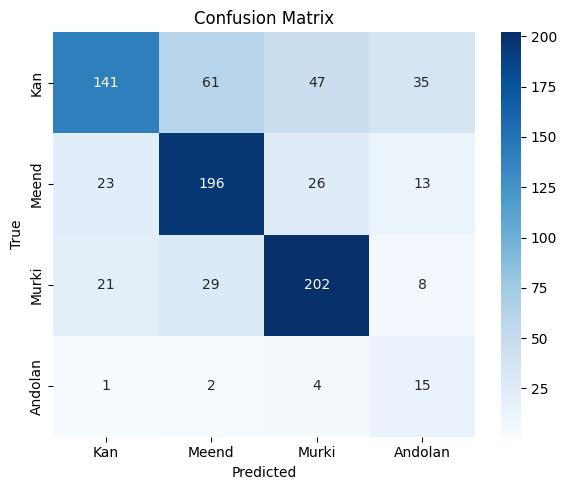


FOLD 5/5
Epoch 01 | Loss: 1.2984 | Train Acc: 0.515 | Test Acc: 0.544
Epoch 02 | Loss: 1.2162 | Train Acc: 0.563 | Test Acc: 0.598
Epoch 03 | Loss: 1.1605 | Train Acc: 0.587 | Test Acc: 0.620
Epoch 04 | Loss: 1.1166 | Train Acc: 0.599 | Test Acc: 0.655
Epoch 05 | Loss: 1.0704 | Train Acc: 0.619 | Test Acc: 0.633
Epoch 06 | Loss: 1.0297 | Train Acc: 0.626 | Test Acc: 0.638
Epoch 07 | Loss: 1.0065 | Train Acc: 0.623 | Test Acc: 0.637
Epoch 08 | Loss: 0.9944 | Train Acc: 0.636 | Test Acc: 0.687
Epoch 09 | Loss: 0.9620 | Train Acc: 0.640 | Test Acc: 0.678
Epoch 10 | Loss: 0.9376 | Train Acc: 0.645 | Test Acc: 0.681
Epoch 11 | Loss: 0.9105 | Train Acc: 0.656 | Test Acc: 0.697
Epoch 12 | Loss: 0.9255 | Train Acc: 0.653 | Test Acc: 0.658
Epoch 13 | Loss: 0.9086 | Train Acc: 0.654 | Test Acc: 0.675
Epoch 14 | Loss: 0.8875 | Train Acc: 0.672 | Test Acc: 0.728
Epoch 15 | Loss: 0.8757 | Train Acc: 0.658 | Test Acc: 0.693
Epoch 16 | Loss: 0.8636 | Train Acc: 0.662 | Test Acc: 0.671
Epoch 17 | Los

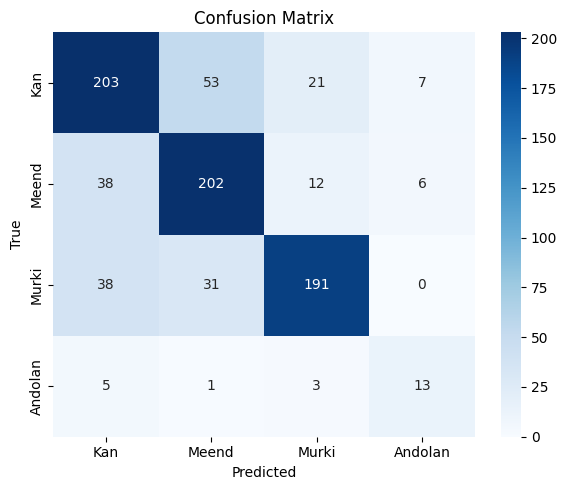


CROSS VALIDATION SUMMARY

Accuracy: 0.707 ± 0.029
Macro F1: 0.650 ± 0.044

Per-class metrics across folds (mean ± std):
Class      |       Precision |          Recall |              F1
-----------------------------------------------------------------
Kan        | 0.737 ± 0.023  | 0.603 ± 0.084  | 0.659 ± 0.048
Meend      | 0.719 ± 0.032  | 0.762 ± 0.023  | 0.739 ± 0.015
Murki      | 0.771 ± 0.042  | 0.765 ± 0.038  | 0.766 ± 0.014
Andolan    | 0.333 ± 0.132  | 0.720 ± 0.080  | 0.434 ± 0.115


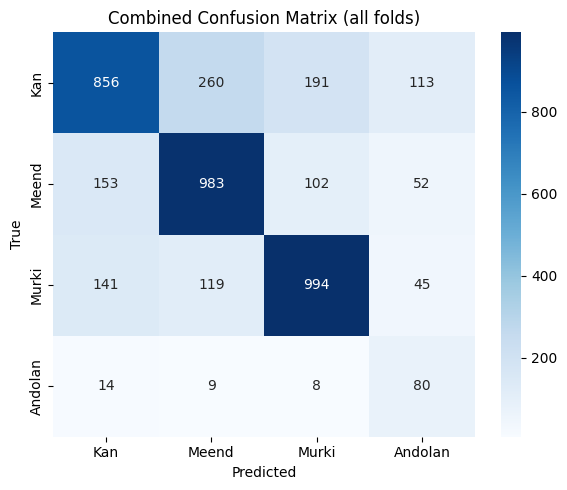

In [18]:
X, y, label_map = prepare_tcn_input(segments_aug, fixed_length=117)
fold_results = cross_validate_tcn(X, y, label_map, n_splits=5, epochs=30)

### Adaptive window

In [19]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
def prepare_tcn_input(segments, min_length=20):
    label_map = {"Kan": 0, "Meend": 1, "Murki": 2, "Andolan": 3}
    
    X, y = [], []
    skipped = 0
    
    # Filter too short
    segments = [s for s in segments if len(s['pitch_curve']) >= min_length]
    
    for seg in segments:
        curve = seg['pitch_curve'].copy()
        label = seg['label']
        
        if label not in label_map:
            skipped += 1
            continue
        
        # Normalize
        if curve.std() > 0:
            curve = (curve - curve.mean()) / curve.std()
        else:
            skipped += 1
            continue
        
        X.append(torch.tensor(curve, dtype=torch.float32).unsqueeze(0))  # (1, length)
        y.append(label_map[label])
    
    y = torch.tensor(y, dtype=torch.int64)
    
    print(f"Total segments: {len(X)}")
    print(f"Skipped: {skipped}")
    print(f"Label distribution: { {k: int((y==v).sum()) for k,v in label_map.items()} }")
    
    return X, y, label_map  # X is now a list of variable length tensors

In [20]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    """Pads sequences in each batch to the longest in that batch."""
    X_batch, y_batch = zip(*batch)
    lengths = torch.tensor([x.shape[-1] for x in X_batch])
    
    # Pad to longest sequence in this batch
    X_padded = pad_sequence(
        [x.squeeze(0) for x in X_batch], 
        batch_first=True
    ).unsqueeze(1)  # (batch, 1, max_len_in_batch)
    
    return X_padded, torch.tensor(y_batch), lengths

In [21]:
from torch.utils.data import Dataset

class OrnamentDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def get_dataloaders(X, y, batch_size=16, test_size=0.2):
    # Split indices
    from sklearn.model_selection import train_test_split
    indices = list(range(len(X)))
    train_idx, test_idx = train_test_split(
        indices, test_size=test_size, 
        stratify=y.numpy(), random_state=42
    )
    
    X_train = [X[i] for i in train_idx]
    X_test  = [X[i] for i in test_idx]
    y_train = y[train_idx]
    y_test  = y[test_idx]
    
    train_ds = OrnamentDataset(X_train, y_train)
    test_ds  = OrnamentDataset(X_test,  y_test)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, 
                              shuffle=True, collate_fn=collate_fn)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, 
                              collate_fn=collate_fn)
    
    print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")
    return train_loader, test_loader

In [22]:
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=padding)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.norm1 = nn.BatchNorm1d(channels)
        self.norm2 = nn.BatchNorm1d(channels)

    def forward(self, x):
        out = self.relu(self.norm1(self.conv1(x)[:, :, :x.size(2)]))
        out = self.dropout(out)
        out = self.relu(self.norm2(self.conv2(out)[:, :, :x.size(2)]))
        return self.relu(out + x)  # residual connection

class OrnamentTCN(nn.Module):
    def __init__(self, input_size=1, num_classes=4, channels=32, kernel_size=3):
        super().__init__()
        self.input_proj = nn.Conv1d(input_size, channels, kernel_size=1)
        self.tcn = nn.Sequential(
            ResidualBlock(channels, kernel_size, dilation=1),
            ResidualBlock(channels, kernel_size, dilation=2),
            ResidualBlock(channels, kernel_size, dilation=4),
            ResidualBlock(channels, kernel_size, dilation=8),
        )
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)  # handles any length
        self.classifier = nn.Linear(channels, num_classes)

    def forward(self, x):
        out = self.input_proj(x)
        out = self.tcn(out)
        out = self.adaptive_pool(out).squeeze(-1)  # (batch, channels)
        return self.classifier(out)

In [23]:
from sklearn.utils.class_weight import compute_class_weight

def train_tcn(train_loader, test_loader, num_classes=4, epochs=30):
    model = OrnamentTCN(input_size=1, num_classes=num_classes)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # Handle class imbalance
    all_labels = train_loader.dataset.y.numpy()
    weights = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float))
    
    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for xb, yb, lengths in train_loader:  # unpack lengths too
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            correct += (preds.argmax(1) == yb).sum().item()
            total += len(yb)
        # Evaluate
        model.eval()
        test_correct, test_total = 0, 0
        with torch.no_grad():
            for xb, yb, lengths in test_loader:
                preds = model(xb)
                test_correct += (preds.argmax(1) == yb).sum().item()
                test_total += len(yb)
        
        print(f"Epoch {epoch+1:02d} | "
              f"Loss: {train_loss/len(train_loader):.4f} | "
              f"Train Acc: {correct/total:.3f} | "
              f"Test Acc: {test_correct/test_total:.3f}")
    
    return model

In [24]:
X, y, label_map = prepare_tcn_input(segments, min_length=20)
train_loader, test_loader = get_dataloaders(X, y, batch_size=16)
model = train_tcn(train_loader, test_loader, epochs=30)

Total segments: 1376
Skipped: 0
Label distribution: {'Kan': 476, 'Meend': 430, 'Murki': 433, 'Andolan': 37}
Train: 1100 | Test: 276
Epoch 01 | Loss: 1.3381 | Train Acc: 0.477 | Test Acc: 0.554
Epoch 02 | Loss: 1.2552 | Train Acc: 0.560 | Test Acc: 0.598
Epoch 03 | Loss: 1.2353 | Train Acc: 0.589 | Test Acc: 0.580
Epoch 04 | Loss: 1.2320 | Train Acc: 0.585 | Test Acc: 0.634
Epoch 05 | Loss: 1.1921 | Train Acc: 0.601 | Test Acc: 0.598
Epoch 06 | Loss: 1.2119 | Train Acc: 0.595 | Test Acc: 0.442
Epoch 07 | Loss: 1.2047 | Train Acc: 0.570 | Test Acc: 0.562
Epoch 08 | Loss: 1.1577 | Train Acc: 0.625 | Test Acc: 0.634
Epoch 09 | Loss: 1.1637 | Train Acc: 0.615 | Test Acc: 0.649
Epoch 10 | Loss: 1.1286 | Train Acc: 0.628 | Test Acc: 0.645
Epoch 11 | Loss: 1.1213 | Train Acc: 0.641 | Test Acc: 0.594
Epoch 12 | Loss: 1.0977 | Train Acc: 0.645 | Test Acc: 0.359
Epoch 13 | Loss: 1.1015 | Train Acc: 0.624 | Test Acc: 0.609
Epoch 14 | Loss: 1.0708 | Train Acc: 0.642 | Test Acc: 0.620
Epoch 15 | Los

=== Classification Report ===
              precision    recall  f1-score   support

         Kan       0.58      0.67      0.62        96
       Meend       0.73      0.70      0.71        86
       Murki       0.86      0.59      0.70        87
     Andolan       0.12      0.43      0.19         7

    accuracy                           0.64       276
   macro avg       0.57      0.59      0.56       276
weighted avg       0.70      0.64      0.66       276

=== Per-class Metrics ===
Kan        | Precision: 0.577 | Recall: 0.667 | F1: 0.618
Meend      | Precision: 0.732 | Recall: 0.698 | F1: 0.714
Murki      | Precision: 0.864 | Recall: 0.586 | F1: 0.699
Andolan    | Precision: 0.125 | Recall: 0.429 | F1: 0.194

Macro avg  | Precision: 0.574 | Recall: 0.595 | F1: 0.556


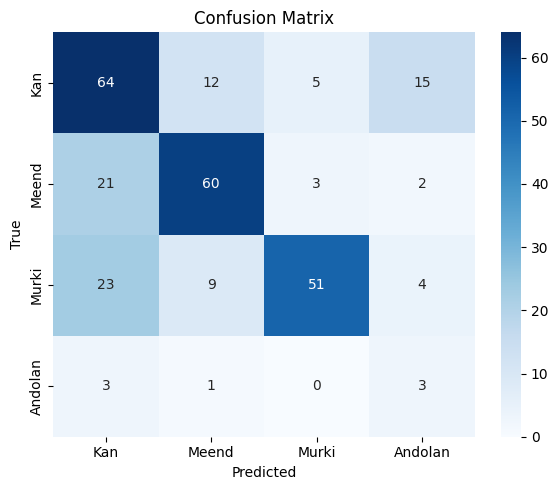

Precision: [0.57657658 0.73170732 0.86440678 0.125     ]
Recall:    [0.66666667 0.69767442 0.5862069  0.42857143]
F1:        [0.61835749 0.71428571 0.69863014 0.19354839]


In [25]:
all_preds, all_labels, precision, recall, f1 = evaluate_model(model, test_loader, label_map)

# Print as arrays
print("Precision:", precision)
print("Recall:   ", recall)
print("F1:       ", f1)